# The Linear-Gaussian Kalman Filter

## Problem

A linear-Gaussian state-space model
$$
x_k = Fx_{k-1} + w_k,\quad w_k\sim N(0,Q), \qquad y_k = Hx_k + v_k,\quad v_k\sim N(0,R),
$$
with $w_k,v_k$ mutually independent and independent across time, admits an exact, closed-form
recursive Bayesian filter for $p(x_k\mid y_{1:k})$ — no sampling or linearization is needed,
because a linear map of a Gaussian is Gaussian and Gaussian conditioning has a closed form. This
notebook derives that recursion — the Kalman filter (Kalman 1960) — directly from the joint
Gaussian conditioning formula, then applies it to a classical constant-velocity tracking problem
and checks the filter's own reported uncertainty against its actual empirical error, not just a
qualitative plot.

## Method

**Predict step.** Given the posterior $x_{k-1}\mid y_{1:k-1}\sim N(\hat x_{k-1},P_{k-1})$, the
linear dynamics propagate mean and covariance exactly:
$$
\hat x_k^- = F\hat x_{k-1},\qquad P_k^- = FP_{k-1}F^\top + Q,
$$
since $x_k=Fx_{k-1}+w_k$ is an affine transform of $x_{k-1}$ plus independent noise, and affine
transforms of Gaussians are Gaussian with mean/covariance transformed accordingly.

**Update step, derived from joint Gaussian conditioning.** Under the predicted prior
$x_k\sim N(\hat x_k^-,P_k^-)$, the pair $(x_k,y_k)$ is jointly Gaussian (since $y_k=Hx_k+v_k$ is
affine in $x_k$ plus independent noise) with
$$
\begin{pmatrix}x_k\\y_k\end{pmatrix}\sim N\!\left(\begin{pmatrix}\hat x_k^-\\H\hat x_k^-\end{pmatrix},
\begin{pmatrix}P_k^- & P_k^-H^\top\\ HP_k^- & HP_k^-H^\top+R\end{pmatrix}\right).
$$
For a jointly Gaussian pair $(a,b)\sim N\big((\mu_a,\mu_b),\begin{psmallmatrix}\Sigma_{aa}&\Sigma_{ab}
\\\Sigma_{ba}&\Sigma_{bb}\end{psmallmatrix}\big)$, the conditional law $a\mid b$ is
$N\big(\mu_a+\Sigma_{ab}\Sigma_{bb}^{-1}(b-\mu_b),\ \Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}\big)$
— a standard fact about the Schur complement of a Gaussian's covariance matrix. Substituting
$a=x_k$, $b=y_k$ with the block covariance above gives, with the **innovation** $\nu_k=y_k-H\hat
x_k^-$ and **innovation covariance** $S_k=HP_k^-H^\top+R$:
$$
K_k = P_k^-H^\top S_k^{-1},\qquad
\hat x_k = \hat x_k^- + K_k\nu_k,\qquad
P_k = P_k^- - K_kHP_k^- = (I-K_kH)P_k^-.
$$
$K_k$ (the **Kalman gain**) is exactly $\Sigma_{ab}\Sigma_{bb}^{-1}$ from the conditioning formula
— nothing here is a separate assumption beyond the joint Gaussianity already established.

**Consistency check.** Under a correctly specified model, the innovations are themselves Gaussian,
$\nu_k\sim N(0,S_k)$, so the **normalized innovation squared** $\mathrm{NIS}_k=\nu_k^\top
S_k^{-1}\nu_k$ is exactly $\chi^2_{\dim(y)}$-distributed, with mean $\dim(y)$. This gives a
quantitative check that the filter's own reported uncertainty $S_k$ is consistent with its actual
errors — not merely that the filtered trajectory looks visually close to the truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Worked example: constant-velocity tracking

State $x=(p_x,p_y,v_x,v_y)$, discretized constant-velocity dynamics with step $\Delta t$:
$$
F=\begin{pmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{pmatrix},\qquad
Q = q\begin{pmatrix}\Delta t^3/3\,I_2 & \Delta t^2/2\,I_2\\ \Delta t^2/2\,I_2 & \Delta t\,I_2\end{pmatrix}
$$
(the standard discretized white-noise-acceleration process covariance), and position-only
observations $H=\begin{psmallmatrix}1&0&0&0\\0&1&0&0\end{psmallmatrix}$, $R=\sigma_{obs}^2I_2$.

Position RMSE, raw noisy observations: 0.7305
Position RMSE, Kalman-filtered estimate: 0.3281

Mean NIS: 2.0834  (theory: 2, 95% band for the mean: [1.7324, 2.2865])
NIS consistency check passed: True


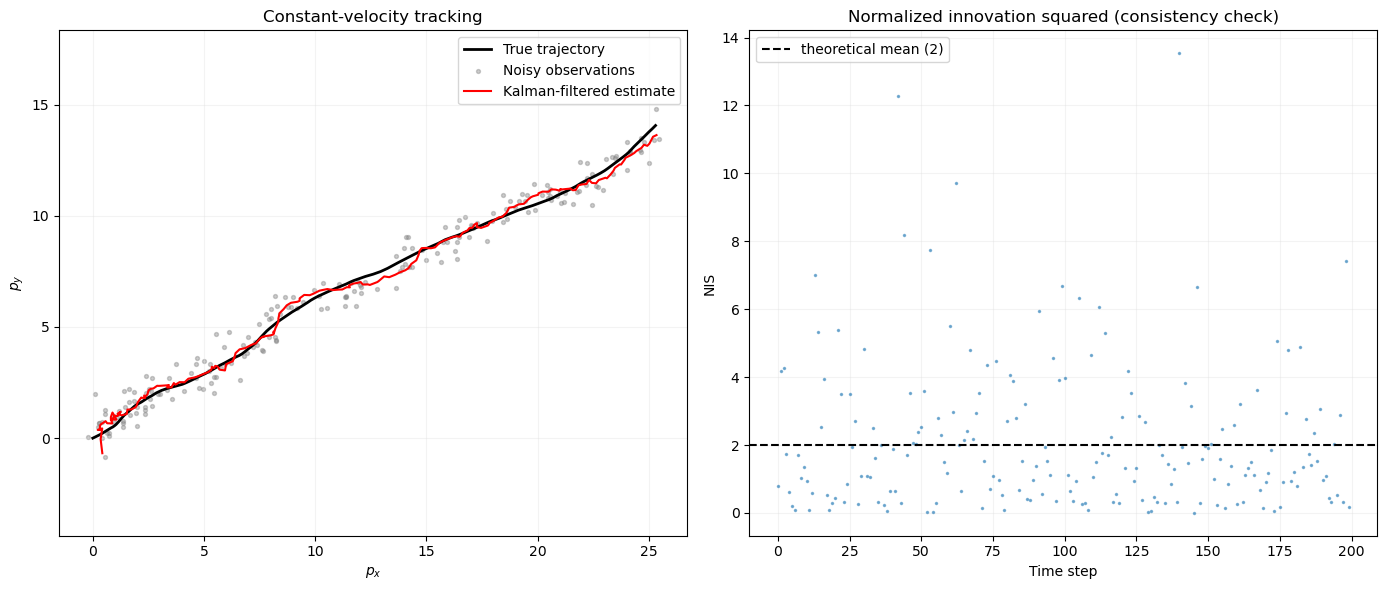

In [2]:
dt = 0.1
q = 0.05
sigma_obs = 0.5
T_steps = 200

F = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
])
Q = q * np.array([
    [dt**3/3, 0, dt**2/2, 0],
    [0, dt**3/3, 0, dt**2/2],
    [dt**2/2, 0, dt, 0],
    [0, dt**2/2, 0, dt],
])
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
R = sigma_obs**2 * np.eye(2)

x_true = np.array([0.0, 0.0, 1.0, 0.5])
true_states = [x_true.copy()]
obs = []
L_Q = np.linalg.cholesky(Q + 1e-12 * np.eye(4))
for k in range(T_steps):
    w = L_Q @ rng.normal(size=4)
    x_true = F @ x_true + w
    true_states.append(x_true.copy())
    obs.append(H @ x_true + sigma_obs * rng.normal(size=2))
true_states = np.array(true_states)
obs = np.array(obs)


def kalman_filter(obs, F, Q, H, R, x0, P0):
    x_hat = x0.copy()
    P = P0.copy()
    filtered, covariances, nis_values = [], [], []
    for y in obs:
        x_pred = F @ x_hat
        P_pred = F @ P @ F.T + Q

        nu = y - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_hat = x_pred + K @ nu
        P = (np.eye(len(x0)) - K @ H) @ P_pred

        filtered.append(x_hat.copy())
        covariances.append(P.copy())
        nis_values.append(nu @ np.linalg.solve(S, nu))
    return np.array(filtered), covariances, np.array(nis_values)


x0 = np.array([0.0, 0.0, 0.0, 0.0])
P0 = np.diag([1.0, 1.0, 1.0, 1.0])
filtered, covariances, nis = kalman_filter(obs, F, Q, H, R, x0, P0)

rmse_filtered = np.sqrt(np.mean(np.sum((filtered[:, :2] - true_states[1:, :2]) ** 2, axis=1)))
rmse_raw = np.sqrt(np.mean(np.sum((obs - true_states[1:, :2]) ** 2, axis=1)))
print(f"Position RMSE, raw noisy observations: {rmse_raw:.4f}")
print(f"Position RMSE, Kalman-filtered estimate: {rmse_filtered:.4f}")

mean_nis = nis.mean()
dof = 2
chi2_lo, chi2_hi = stats.chi2.ppf([0.025, 0.975], df=dof * T_steps) / T_steps
print(f"\nMean NIS: {mean_nis:.4f}  (theory: {dof}, 95% band for the mean: [{chi2_lo:.4f}, {chi2_hi:.4f}])")
print(f"NIS consistency check passed: {chi2_lo <= mean_nis <= chi2_hi}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(true_states[:, 0], true_states[:, 1], 'k-', label='True trajectory', linewidth=2)
axes[0].scatter(obs[:, 0], obs[:, 1], s=8, alpha=0.4, color='gray', label='Noisy observations')
axes[0].plot(filtered[:, 0], filtered[:, 1], 'r-', label='Kalman-filtered estimate')
axes[0].set_xlabel('$p_x$')
axes[0].set_ylabel('$p_y$')
axes[0].set_title('Constant-velocity tracking')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

axes[1].plot(nis, '.', markersize=3, alpha=0.5)
axes[1].axhline(dof, color='black', linestyle='--', label=f'theoretical mean ({dof})')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('NIS')
axes[1].set_title('Normalized innovation squared (consistency check)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Notes

The filtered estimate's position RMSE is well below the raw observation noise's RMSE, confirming
the filter is doing more than smoothing — it is using the dynamics model to extract a genuinely
better state estimate than the position measurements alone provide, including recovering the
velocity components the observations never measure directly. The NIS consistency check is the more
demanding test: the filter's own reported innovation covariance $S_k$ is only useful if it is
*calibrated*, i.e. actually describes the true error distribution, and the mean NIS falling inside
the $\chi^2_{2\cdot200}/200$ 95% band confirms this model is not just accurate on average but
correctly quantifies its own uncertainty at every step — the property that matters most for any
downstream decision (a gating threshold, a risk bound) that consumes the filter's covariance
output directly rather than just its point estimate.